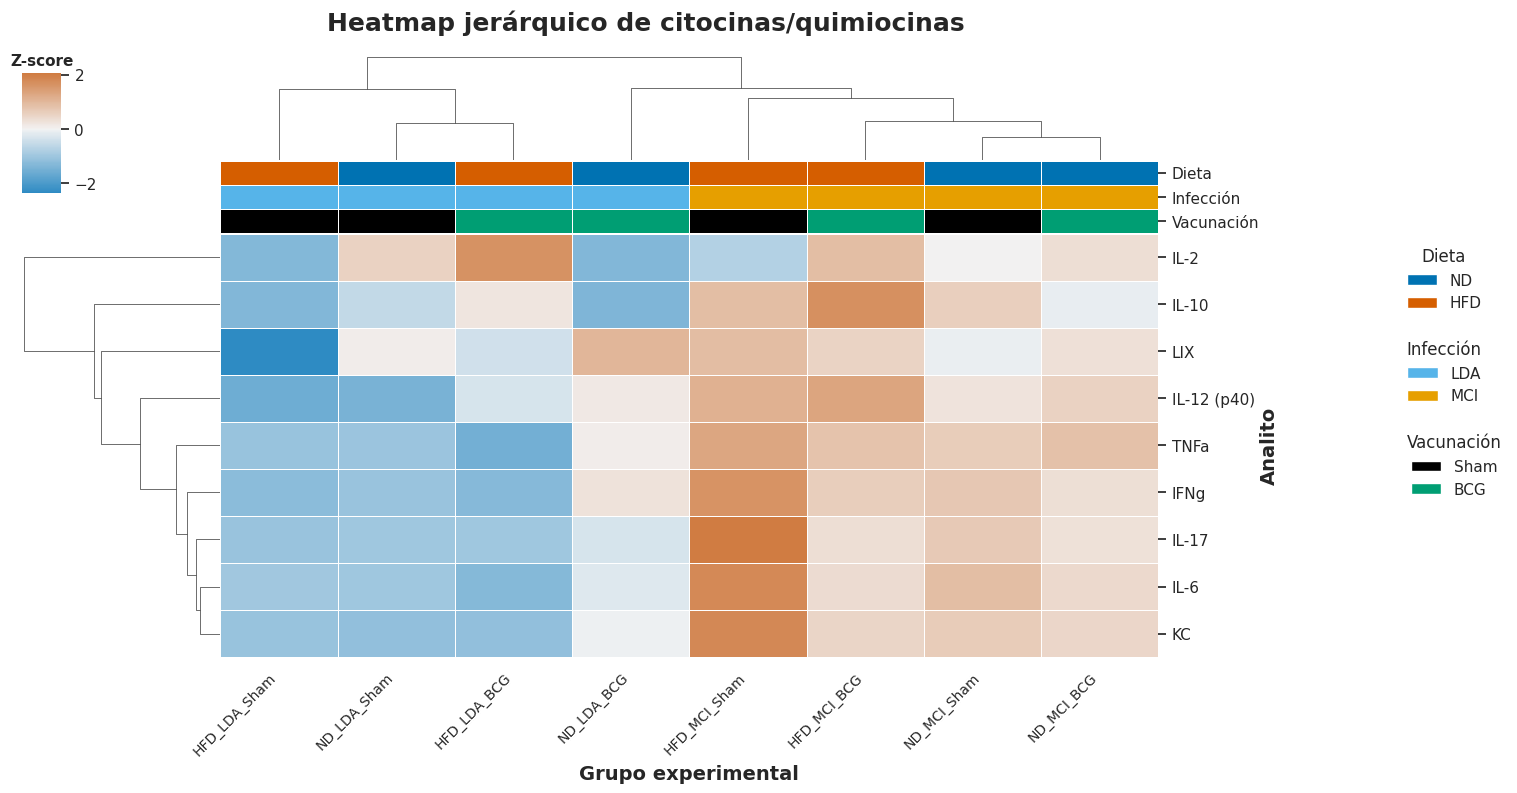

Archivos generados:
- heatmap_luminex_clustermap_okabe_ito.png
- heatmap_luminex_clustermap_okabe_ito.pdf
- heatmap_luminex_clustermap_okabe_ito.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================
# HEATMAP JERÁRQUICO LUMINEX
# Dendrogramas + barras de anotación
# Paleta Okabe-Ito + heatmap azul/naranja apto para daltonismo
# ============================================================

!pip install -q pandas openpyxl scipy seaborn matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from google.colab import files
import base64

# ============================================================
# 1. Cargar datos desde GitHub
# ============================================================

url_datos = (
    "https://raw.githubusercontent.com/"
    "pjcardona-sketch/"
    "Dieta_vacunacio-n_Citocinas/"
    "main/"
    "Dieta_vacunacion_citocinas.xlsx"
)

df = pd.read_excel(
    url_datos,
    sheet_name="tidy_luminex"
)

# ============================================================
# 2. Limpieza básica
# ============================================================

df = df.dropna(
    subset=["diet", "infection", "vaccination", "analyte", "value"]
)

for col in ["diet", "infection", "vaccination", "analyte"]:
    df[col] = df[col].astype(str).str.strip()

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])
df = df[df["value"] > 0].copy()

# ============================================================
# 3. Grupo experimental y transformación log10
# ============================================================

df["experimental_group"] = (
    df["diet"] + "_" + df["infection"] + "_" + df["vaccination"]
)

df["log10_value"] = np.log10(df["value"])

summary = (
    df.groupby(
        ["experimental_group", "diet", "infection", "vaccination", "analyte"],
        observed=True
    )
    .agg(
        mean_log10=("log10_value", "mean"),
        sd_log10=("log10_value", "std"),
        n=("log10_value", "count")
    )
    .reset_index()
)

# ============================================================
# 4. Z-score por analito
# ============================================================

summary["z_score"] = (
    summary
    .groupby("analyte")["mean_log10"]
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)

summary = summary.dropna(subset=["z_score"])

# ============================================================
# 5. Matriz analito × grupo experimental
# ============================================================

matrix = summary.pivot(
    index="analyte",
    columns="experimental_group",
    values="z_score"
).fillna(0)

orden_grupos = [
    "ND_LDA_Sham",
    "ND_LDA_BCG",
    "ND_MCI_Sham",
    "ND_MCI_BCG",
    "HFD_LDA_Sham",
    "HFD_LDA_BCG",
    "HFD_MCI_Sham",
    "HFD_MCI_BCG"
]

columnas_presentes = [g for g in orden_grupos if g in matrix.columns]
columnas_extra = [g for g in matrix.columns if g not in columnas_presentes]

matrix = matrix[columnas_presentes + columnas_extra]

# ============================================================
# 6. Paleta Okabe-Ito para anotaciones
# ============================================================

okabe_ito = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000"
}

diet_palette = {
    "ND": okabe_ito["blue"],
    "HFD": okabe_ito["vermillion"]
}

infection_palette = {
    "LDA": okabe_ito["sky_blue"],
    "MCI": okabe_ito["orange"]
}

vaccination_palette = {
    "Sham": okabe_ito["black"],
    "BCG": okabe_ito["bluish_green"]
}

metadata = (
    summary[["experimental_group", "diet", "infection", "vaccination"]]
    .drop_duplicates()
    .set_index("experimental_group")
)

metadata = metadata.loc[matrix.columns]

col_colors = pd.DataFrame(
    {
        "Dieta": metadata["diet"].map(diet_palette),
        "Infección": metadata["infection"].map(infection_palette),
        "Vacunación": metadata["vaccination"].map(vaccination_palette)
    },
    index=metadata.index
)

# ============================================================
# 7. Heatmap jerárquico con dendrogramas integrados
# ============================================================

sns.set_theme(context="notebook", style="white")

cmap_daltonicos = sns.diverging_palette(
    240, 30,
    s=90,
    l=55,
    as_cmap=True
)

g = sns.clustermap(
    matrix,
    method="average",
    metric="euclidean",
    cmap=cmap_daltonicos,
    center=0,
    col_colors=col_colors,
    linewidths=0.5,
    linecolor="white",
    figsize=(13, 8),
    dendrogram_ratio=(0.18, 0.18),
    colors_ratio=(0.04, 0.04),
    cbar_pos=(0.02, 0.80, 0.03, 0.15)
)

# ============================================================
# 8. Personalización estética
# ============================================================

g.ax_heatmap.set_xlabel(
    "Grupo experimental",
    fontsize=14,
    fontweight="bold"
)

g.ax_heatmap.set_ylabel(
    "Analito",
    fontsize=14,
    fontweight="bold"
)

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10
)

g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=11
)

g.cax.set_title(
    "Z-score",
    fontsize=11,
    fontweight="bold"
)

g.fig.suptitle(
    "Heatmap jerárquico de citocinas/quimiocinas",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

# ============================================================
# 9. Leyendas manuales
# ============================================================

legend_diet = [
    Patch(facecolor=diet_palette["ND"], label="ND"),
    Patch(facecolor=diet_palette["HFD"], label="HFD")
]

legend_infection = [
    Patch(facecolor=infection_palette["LDA"], label="LDA"),
    Patch(facecolor=infection_palette["MCI"], label="MCI")
]

legend_vaccination = [
    Patch(facecolor=vaccination_palette["Sham"], label="Sham"),
    Patch(facecolor=vaccination_palette["BCG"], label="BCG")
]

ax = g.ax_heatmap

leg1 = ax.legend(
    handles=legend_diet,
    title="Dieta",
    loc="upper left",
    bbox_to_anchor=(1.25, 1.00),
    frameon=False
)
ax.add_artist(leg1)

leg2 = ax.legend(
    handles=legend_infection,
    title="Infección",
    loc="upper left",
    bbox_to_anchor=(1.25, 0.78),
    frameon=False
)
ax.add_artist(leg2)

leg3 = ax.legend(
    handles=legend_vaccination,
    title="Vacunación",
    loc="upper left",
    bbox_to_anchor=(1.25, 0.56),
    frameon=False
)

# ============================================================
# 10. Guardar figura en PNG, PDF y HTML
# ============================================================

png_file = "heatmap_luminex_clustermap_okabe_ito.png"
pdf_file = "heatmap_luminex_clustermap_okabe_ito.pdf"
html_file = "heatmap_luminex_clustermap_okabe_ito.html"

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# Crear HTML con la imagen PNG incrustada
with open(png_file, "rb") as img:
    encoded = base64.b64encode(img.read()).decode("utf-8")

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Heatmap Luminex</title>
</head>
<body style="font-family: Arial, sans-serif;">
    <h1>Heatmap jerárquico de citocinas/quimiocinas</h1>
    <p>
        Heatmap con dendrogramas jerárquicos, z-score por analito,
        barras de anotación para dieta, infección y vacunación,
        y paleta compatible con daltonismo basada en Okabe-Ito.
    </p>
    <img src="data:image/png;base64,{encoded}" style="max-width:100%; height:auto;">
</body>
</html>
"""

with open(html_file, "w", encoding="utf-8") as f:
    f.write(html_content)

print("Archivos generados:")
print("-", png_file)
print("-", pdf_file)
print("-", html_file)

# ============================================================
# 11. Descargar archivos
# ============================================================

files.download(html_file)
files.download(png_file)
files.download(pdf_file)